In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline

import seaborn as sns
sns.set_theme()

### Loading Data

In [2]:
data=pd.read_csv('nursery.data', sep=',', header=None)
data.columns=['parents', 'has_nurs', 'form', 'children', 'housing',
              'finance', 'social', 'health', 'class']
data.head()

,parents,has_nurs,form,children,housing,finance,social,health,class
0,usual,proper,complete,1,convenient,convenient,nonprob,recommended,recommend
1,usual,proper,complete,1,convenient,convenient,nonprob,priority,priority
2,usual,proper,complete,1,convenient,convenient,nonprob,not_recom,not_recom
3,usual,proper,complete,1,convenient,convenient,slightly_prob,recommended,recommend
4,usual,proper,complete,1,convenient,convenient,slightly_prob,priority,priority


In [3]:
data['class'].value_counts()

class
not_recom     4320
priority      4266
spec_prior    4044
very_recom     328
recommend        2
Name: count, dtype: int64

We can see that the class `spec_prior` and `very_recom` are not present in the documentation and `recommend` only has two instances. Therefore we merge these classes into one and call it `recommend` as it allows us to stay consistent with the documentation.

In [4]:
data.loc[data['class'].isin(['spec_prior', 'very_recom']) , 'class']='recommend'
data['class'].value_counts()

class
recommend    4374
not_recom    4320
priority     4266
Name: count, dtype: int64

# Task 1

The data is split into `temp` and `test`. And `temp` is further split into `train` and `validation` subsets. The latter is done through `ShuffleSplit` instance that only makes one split. This way of splitting allows for use of GridSearchCV that helps in tuning the hyperparameters of the models. All the experiments are performed with 10% test data and out of the remaining 90% of the data, 20% is reserved for validation. Remaining data is used for training.

In [5]:
def split_test_data(X, y, random_state=None):
    X_temp, X_test, y_temp, y_test=train_test_split(X, y, test_size=0.1, random_state=random_state)
    return X_temp, X_test, y_temp, y_test

In [6]:
X, y=data.drop('class', axis=1), data['class']
X_temp, X_test, y_temp, y_test=split_test_data(X, y, random_state=1)

### Decision Tree (categorical features encoded using label encoder)

Function to tune the Decision Tree pipeline. The function return the grid search instance that contains the best hyperparameters and tuned classifier.

In [7]:
def tune_dt(X, y, model, random_state=None):
    valid_splitter=ShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    gscv=GridSearchCV(model, param_grid={'clsf__criterion': ['gini', 'entropy', 'log_loss'],
                                                'clsf__max_features': [None, 'sqrt', 'log2'],
                                                'clsf__max_depth': [None] + list(range(1, 20, 2))
                                        },
                        n_jobs=-1, cv=valid_splitter)
    gscv.fit(X, y)
    return gscv


Pipeline that encodes the data and fits the Decision Tree

In [8]:
pipeline=Pipeline(steps=[('encoder', OrdinalEncoder()),
                         ('clsf', DecisionTreeClassifier(random_state=1))])

In [9]:
gscv=tune_dt(X_temp, y_temp, model=pipeline, random_state=1)

Best Parameters

In [10]:
print('Best Parameters: ', end='\t')
print(gscv.best_params_), 
print('Best Validation Score: ', end='\t')
print(gscv.best_score_)
print('Test Score: ', end='\t')
print(gscv.score(X_test, y_test))

Best Parameters: 	{'clsf__criterion': 'gini', 'clsf__max_depth': None, 'clsf__max_features': None}
Best Validation Score: 	0.9888555507929704
Test Score: 	0.9969135802469136


### Decision Tree (categorical features encoded using OneHotEncoder)

Pipeline that encodes the data and fits the Decision Tree

In [11]:
pipeline=Pipeline(steps=[('encoder', OneHotEncoder()),
                         ('clsf', DecisionTreeClassifier(random_state=1))])

In [12]:
gscv=tune_dt(X_temp, y_temp, model=pipeline, random_state=1)

In [13]:
print('Best Parameters: ', end='\t')
print(gscv.best_params_), 
print('Best Validation Score: ', end='\t')
print(gscv.best_score_)
print('Test Score: ', end='\t')
print(gscv.score(X_test, y_test))

Best Parameters: 	{'clsf__criterion': 'entropy', 'clsf__max_depth': None, 'clsf__max_features': None}
Best Validation Score: 	0.994856408058294
Test Score: 	0.9953703703703703


### Logistic Regression (with L1 regularization)

Function to tune the Logistic Regression pipeline. The function return the grid search instance that contains the best hyperparameters and tuned classifier.

In [14]:
def tune_lr(X, y, model, random_state=None):
    valid_splitter=ShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    gscv=GridSearchCV(model, param_grid={'clsf__C': np.linspace(0.1, 1, 10),
                                                'clsf__fit_intercept': [True, False],
                                                'clsf__solver': ['saga'],
                                                'clsf__intercept_scaling': np.linspace(1, 5, 5),
                                                'clsf__max_iter': [100, 200, 300]
                                        },
                        n_jobs=-1, cv=valid_splitter)
    gscv.fit(X, y)
    return gscv


Pipeline that encodes the data and fits the Logistic Regression

In [15]:
pipeline=Pipeline(steps=[('encoder', OneHotEncoder()),
                         ('clsf', LogisticRegression(penalty='l1', random_state=1))])

In [16]:
gscv=tune_lr(X_temp, y_temp, model=pipeline, random_state=1)

d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [17]:
print('Best Parameters: ', end='\t')
print(gscv.best_params_), 
print('Best Validation Score: ', end='\t')
print(gscv.best_score_)
print('Test Score: ', end='\t')
print(gscv.score(X_test, y_test))

Best Parameters: 	{'clsf__C': np.float64(0.4), 'clsf__fit_intercept': True, 'clsf__intercept_scaling': np.float64(1.0), 'clsf__max_iter': 100, 'clsf__solver': 'saga'}
Best Validation Score: 	0.9082726103729104
Test Score: 	0.9143518518518519


### KNN

Function to tune the KNN pipeline. The function returns the grid search instance that contains the best hyperparameters and tuned classifier.

In [18]:
def tune_knn(X, y, model, random_state=None):
    valid_splitter=ShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    gscv=GridSearchCV(model, param_grid={'clsf__n_neighbors': [5, 7, 11, 13, 15],
                                                'clsf__weights': ['uniform', 'distance'],
                                        },
                        n_jobs=-1, cv=valid_splitter)
    gscv.fit(X, y)
    return gscv


Pipeline that encodes the data and fits the KNN Classifier

In [19]:
pipeline=Pipeline(steps=[('encoder', OneHotEncoder(sparse_output=False)),
                         ('clsf', KNeighborsClassifier())])

In [20]:
gscv=tune_knn(X_temp, y_temp, model=pipeline, random_state=1)

In [21]:
print('Best Parameters: ', end='\t')
print(gscv.best_params_), 
print('Best Validation Score: ', end='\t')
print(gscv.best_score_)
print('Test Score: ', end='\t')
print(gscv.score(X_test, y_test))

Best Parameters: 	{'clsf__n_neighbors': 11, 'clsf__weights': 'uniform'}
Best Validation Score: 	0.9682811830261466
Test Score: 	0.966820987654321


Repeating the Experiment and Plotting the Result

In [22]:
def repeat_experiment(X, y, n=5):
    result={}
    for key, func in [('DT Cat', tune_dt), ('DT OHE', tune_dt), ('Logistic', tune_lr), ('KNN', tune_knn)]:
        result[key]={'scores': [], 'tuner': func}

    for i in range(n):
        X_temp, X_test, y_temp, y_test=split_test_data(X, y, random_state=i)

        pipeline_dt_ord=Pipeline(steps=[('encoder', OrdinalEncoder()),
                         ('clsf', DecisionTreeClassifier(random_state=i))])
        result['DT Cat']['model']=pipeline_dt_ord

        pipeline_dt_ohe=Pipeline(steps=[('encoder', OneHotEncoder()),
                         ('clsf', DecisionTreeClassifier(random_state=i))])
        result['DT OHE']['model']=pipeline_dt_ohe

        pipeline_lr=Pipeline(steps=[('encoder', OneHotEncoder()),
                         ('clsf', LogisticRegression(penalty='l1', random_state=i))])
        result['Logistic']['model']=pipeline_lr

        pipeline_knn=Pipeline(steps=[('encoder', OneHotEncoder(sparse_output=False)),
                         ('clsf', KNeighborsClassifier())])
        result['KNN']['model']=pipeline_knn

        for key in result.keys():
            gscv=result[key]['tuner'](X_temp, y_temp, model=result[key]['model'], random_state=i)
            result[key]['scores'].append(gscv.score(X_test, y_test))

    for key in result.keys():
        result[key]['mean_score']=np.mean(result[key]['scores'])*100
        result[key]['std_score']=np.std(result[key]['scores'])*100
    
    return {key: {'mean_score': result[key]['mean_score'],
                  'std_score': result[key]['std_score']} for key in result.keys()}


In [23]:
result=repeat_experiment(X, y, 5)

d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\msc\workspace\dal\.venv\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [30]:
result['XgBoost']={}
result['XgBoost']['mean_score']=99.969
result['XgBoost']['std_score']=100-99.969

result['SVM']={}
result['SVM']['mean_score']=99.198
result['SVM']['std_score']=99.457-99.198

result['RandomForrest']={}
result['RandomForrest']['mean_score']=98.025
result['RandomForrest']['std_score']=98.488-98.025

result['NeuralNetwork']={}
result['NeuralNetwork']['mean_score']=100
result['NeuralNetwork']['std_score']=0

result

{'DT Cat': {'mean_score': np.float64(99.61419753086422),
  'std_score': np.float64(0.10912141684977633)},
 'DT OHE': {'mean_score': np.float64(99.75308641975309),
  'std_score': np.float64(0.2149442635367923)},
 'Logistic': {'mean_score': np.float64(91.7283950617284),
  'std_score': np.float64(0.8024691358024676)},
 'KNN': {'mean_score': np.float64(97.57716049382715),
  'std_score': np.float64(0.5269558974988833)},
 'XgBoost': {'mean_score': 99.969, 'std_score': 0.03100000000000591},
 'SVM': {'mean_score': 99.198, 'std_score': 0.25900000000000034},
 'RandomForrest': {'mean_score': 98.025, 'std_score': 0.46299999999999386},
 'NeuralNetwork': {'mean_score': 100, 'std_score': 0}}

In [31]:
def give_plot_data(key):
      data=[result[key]['mean_score'],
            np.min([result[key]['mean_score']+result[key]['std_score'], 100]),
            np.max([result[key]['mean_score']-result[key]['std_score'], 0])]
      return data

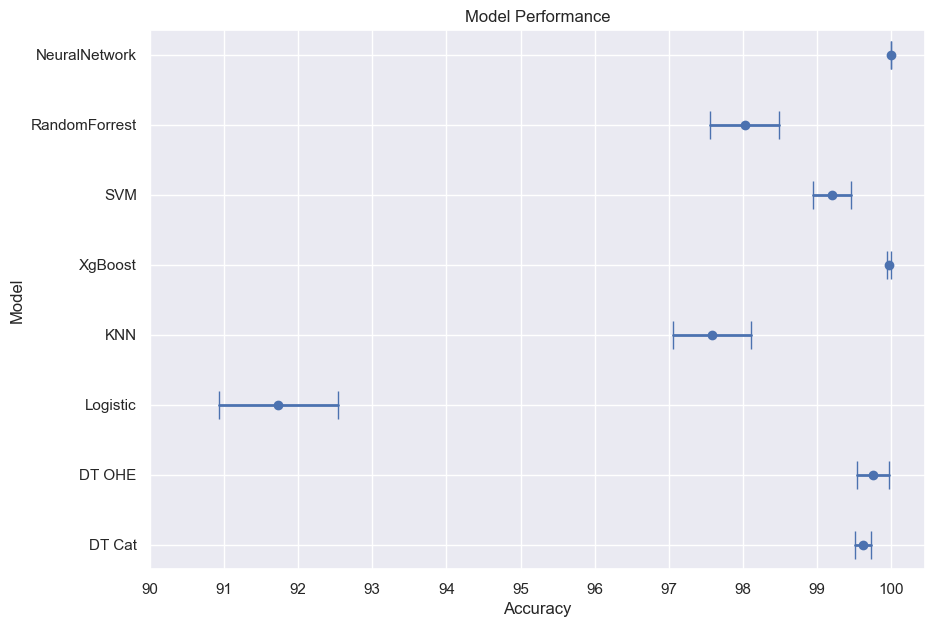

In [32]:
keys, y_vals=result.keys(), range(len(result.keys()))
for key, i in zip(keys, y_vals):
    data=give_plot_data(key)
    plt.plot(data[1:], [i,i], marker='|', markersize=20, c='b', linewidth=2)
    plt.plot(data[0], [i], marker='o', markersize=6, c='b')

plt.xticks(np.linspace(90, 100, 11))
plt.yticks(y_vals, keys)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('Model Performance')
plt.gcf().set_size_inches(10, 7)

### Inferences
* NeuralNetwork has the best performance among all the tried models.
* Logistic Regression has the worst performance among the tries models with accuracy roughly between 91-93%. It also has the maximum variance among all the models.
* Decision Tree with one hot encoding performs better as compared to it with label/ordinal encoding.
* Except Logistic Regression, all models cross the cutoff performance of 95%.

# Task 2

$BipolarSigmoid(ax)=2sigmoid(ax)-1$

Instead of the usual range of $(0, 1)$ of the $sigmoid$ function, this simple change shifts the range to $(-1, 1)$

In [27]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

def bipolar_sigmoid(x, a=1):
    return 2*sigmoid(a*x) - 1

Text(0.5, 1.0, 'Different Functions')

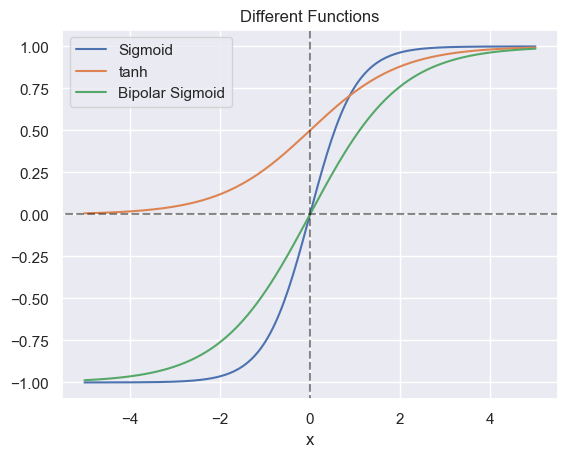

In [33]:
x=np.linspace(-5, 5, 200)
tanh=np.tanh(x)
sig=sigmoid(x)
bsig=bipolar_sigmoid(x)
plt.plot(x, tanh)
plt.plot(x, sig)
plt.plot(x, bsig)
plt.axhline(0, -5, 5, alpha=0.5, linestyle='--', c='k')
plt.axvline(0, -1, 1, alpha=0.5, linestyle='--', c='k')
plt.legend(['Sigmoid', 'tanh', 'Bipolar Sigmoid'])
plt.xlabel('x')
plt.title('Different Functions')

Text(0.5, 1.0, 'tanh(ax) for different a')

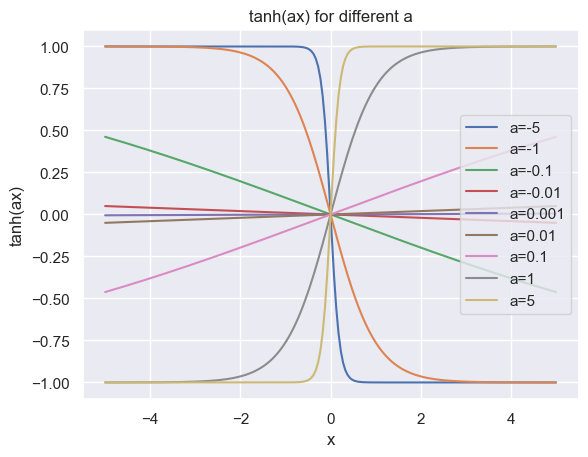

In [29]:
for a in [-5, -1, -0.1, -0.01, 0.001, 0.01, 0.1, 1, 5]:
    plt.plot(x, np.tanh(a*x), label='a=%s'%a)
plt.legend()
plt.xlabel('x')
plt.ylabel('tanh(ax)')
plt.title('tanh(ax) for different a')

Text(0.5, 1.0, 'bipolar_sigmoid(ax) for different a')

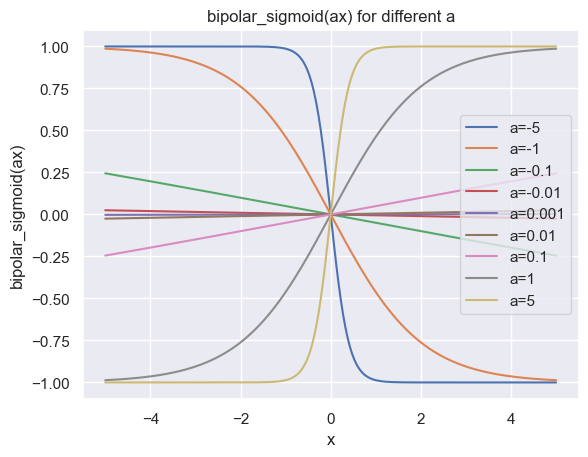

In [34]:
for a in [-5, -1, -0.1, -0.01, 0.001, 0.01, 0.1, 1, 5]:
    plt.plot(x, bipolar_sigmoid(x, a), label='a=%s'%a)
plt.legend()
plt.xlabel('x')
plt.ylabel('bipolar_sigmoid(ax)')
plt.title('bipolar_sigmoid(ax) for different a')